In [1]:
!pip install numpy matplotlib scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.1 MB/s eta 0:00:00


# LAB 3 — Sistema de Inferência Fuzzy

## 1. Definição do problema

O objetivo deste projeto é desenvolver um sistema de inferência fuzzy
para determinar o nível de alerta de um ambiente a partir de duas
informações: o nível de ruído e a intensidade de movimento detectada.

O ruído será medido em decibéis (dB), enquanto o movimento será
representado em uma escala de 0 a 10. A saída do sistema será um
nível de alerta entre 0% e 100%.

A lógica fuzzy é adequada porque conceitos como "baixo", "médio" e
"alto" não possuem necessariamente limites exatos. Dessa forma,
o sistema pode trabalhar com situações intermediárias e produzir
uma resposta gradual.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# ============================================
# VARIÁVEIS LINGUÍSTICAS
# ============================================

# Entrada 1: nível de ruído (0 a 100 dB)
ruido = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "ruido"
)

# Entrada 2: intensidade do movimento (0 a 10)
movimento = ctrl.Antecedent(
    np.arange(0, 10.1, 0.1),
    "movimento"
)

# Saída: nível de alerta (0 a 100%)
alerta = ctrl.Consequent(
    np.arange(0, 101, 1),
    "alerta"
)

print("Variáveis fuzzy criadas com sucesso!")

Variáveis fuzzy criadas com sucesso!


In [3]:
# ============================================
# FUNÇÕES DE PERTINÊNCIA
# ============================================

# ---------- RUÍDO ----------
ruido["baixo"] = fuzz.trapmf(
    ruido.universe,
    [0, 0, 30, 50]
)

ruido["medio"] = fuzz.trimf(
    ruido.universe,
    [30, 55, 75]
)

ruido["alto"] = fuzz.trapmf(
    ruido.universe,
    [60, 80, 100, 100]
)


# ---------- MOVIMENTO ----------
movimento["parado"] = fuzz.trapmf(
    movimento.universe,
    [0, 0, 2, 4]
)

movimento["leve"] = fuzz.trimf(
    movimento.universe,
    [2, 5, 8]
)

movimento["intenso"] = fuzz.trapmf(
    movimento.universe,
    [6, 8, 10, 10]
)


# ---------- ALERTA ----------
alerta["baixo"] = fuzz.trimf(
    alerta.universe,
    [0, 0, 40]
)

alerta["medio"] = fuzz.trimf(
    alerta.universe,
    [20, 50, 80]
)

alerta["alto"] = fuzz.trimf(
    alerta.universe,
    [60, 100, 100]
)

print("Funções de pertinência criadas com sucesso!")

Funções de pertinência criadas com sucesso!


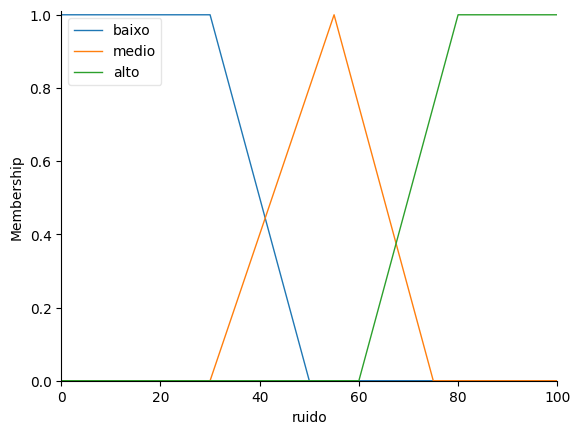

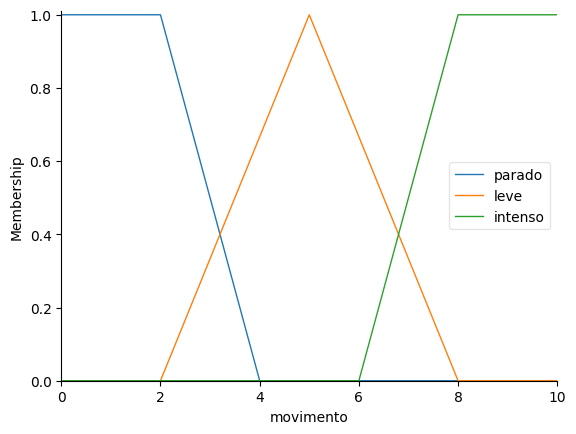

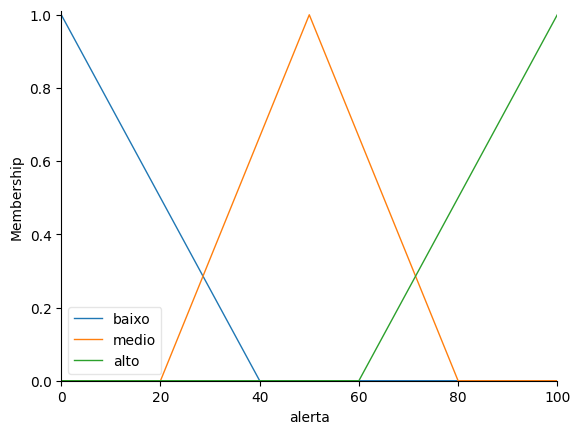

In [4]:
# ============================================
# GRÁFICOS DAS FUNÇÕES DE PERTINÊNCIA
# ============================================

ruido.view()
movimento.view()
alerta.view()

plt.show()

In [5]:
# ============================================
# REGRAS FUZZY
# ============================================

regras = [

    # Regra 1
    ctrl.Rule(
        ruido["baixo"] & movimento["parado"],
        alerta["baixo"]
    ),

    # Regra 2
    ctrl.Rule(
        ruido["baixo"] & movimento["leve"],
        alerta["baixo"]
    ),

    # Regra 3
    ctrl.Rule(
        ruido["baixo"] & movimento["intenso"],
        alerta["medio"]
    ),

    # Regra 4
    ctrl.Rule(
        ruido["medio"] & movimento["parado"],
        alerta["baixo"]
    ),

    # Regra 5
    ctrl.Rule(
        ruido["medio"] & movimento["leve"],
        alerta["medio"]
    ),

    # Regra 6
    ctrl.Rule(
        ruido["medio"] & movimento["intenso"],
        alerta["alto"]
    ),

    # Regra 7
    ctrl.Rule(
        ruido["alto"] & movimento["parado"],
        alerta["medio"]
    ),

    # Regra 8
    ctrl.Rule(
        ruido["alto"] & movimento["leve"],
        alerta["alto"]
    ),

    # Regra 9 - utiliza OU
    ctrl.Rule(
        ruido["alto"] | movimento["intenso"],
        alerta["alto"]
    ),
]

print(f"{len(regras)} regras fuzzy criadas com sucesso!")

9 regras fuzzy criadas com sucesso!


In [6]:
# ============================================
# SISTEMA DE CONTROLE FUZZY
# ============================================

sistema = ctrl.ControlSystem(regras)

sim = ctrl.ControlSystemSimulation(sistema)

print("Sistema de controle fuzzy criado com sucesso!")

Sistema de controle fuzzy criado com sucesso!


In [7]:
# ============================================
# TESTES DO SISTEMA FUZZY
# ============================================

testes = [
    ("Ambiente tranquilo", 20, 1),
    ("Movimento moderado", 50, 5),
    ("Muito movimento", 30, 9),
    ("Ruído elevado", 85, 2),
    ("Ruído e movimento altos", 90, 9),
]

print("=" * 60)
print("RESULTADOS DOS TESTES")
print("=" * 60)

for nome, valor_ruido, valor_movimento in testes:

    sim.input["ruido"] = valor_ruido
    sim.input["movimento"] = valor_movimento

    sim.compute()

    resultado = sim.output["alerta"]

    print(
        f"{nome}: "
        f"ruído = {valor_ruido} dB, "
        f"movimento = {valor_movimento}, "
        f"alerta = {resultado:.1f}%"
    )

RESULTADOS DOS TESTES
Ambiente tranquilo: ruído = 20 dB, movimento = 1, alerta = 13.3%
Movimento moderado: ruído = 50 dB, movimento = 5, alerta = 50.0%
Muito movimento: ruído = 30 dB, movimento = 9, alerta = 64.3%
Ruído elevado: ruído = 85 dB, movimento = 2, alerta = 64.3%
Ruído e movimento altos: ruído = 90 dB, movimento = 9, alerta = 86.7%


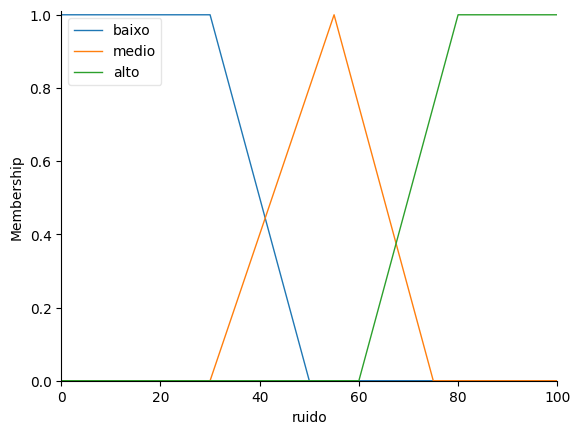

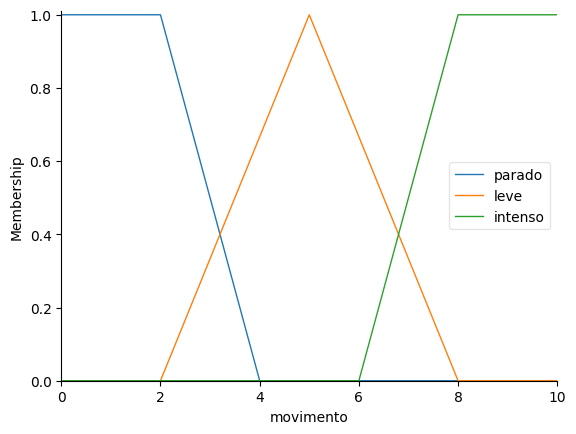

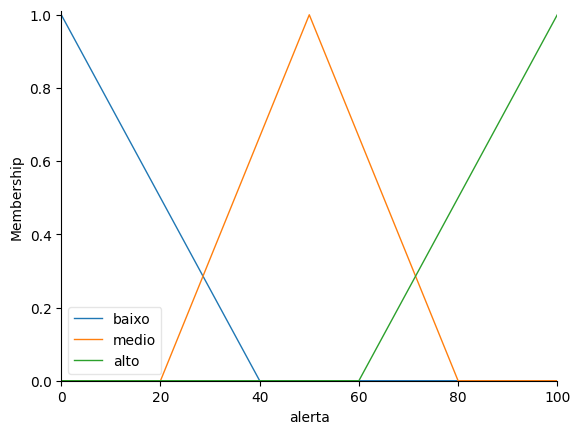

In [8]:
# ============================================
# GRÁFICOS DO SISTEMA FUZZY
# ============================================

ruido.view()
movimento.view()
alerta.view()

plt.show()